## Pises G7

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_12052\3562785952.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_g7["Decade"] = (df_g7["Year"] // 10) * 10


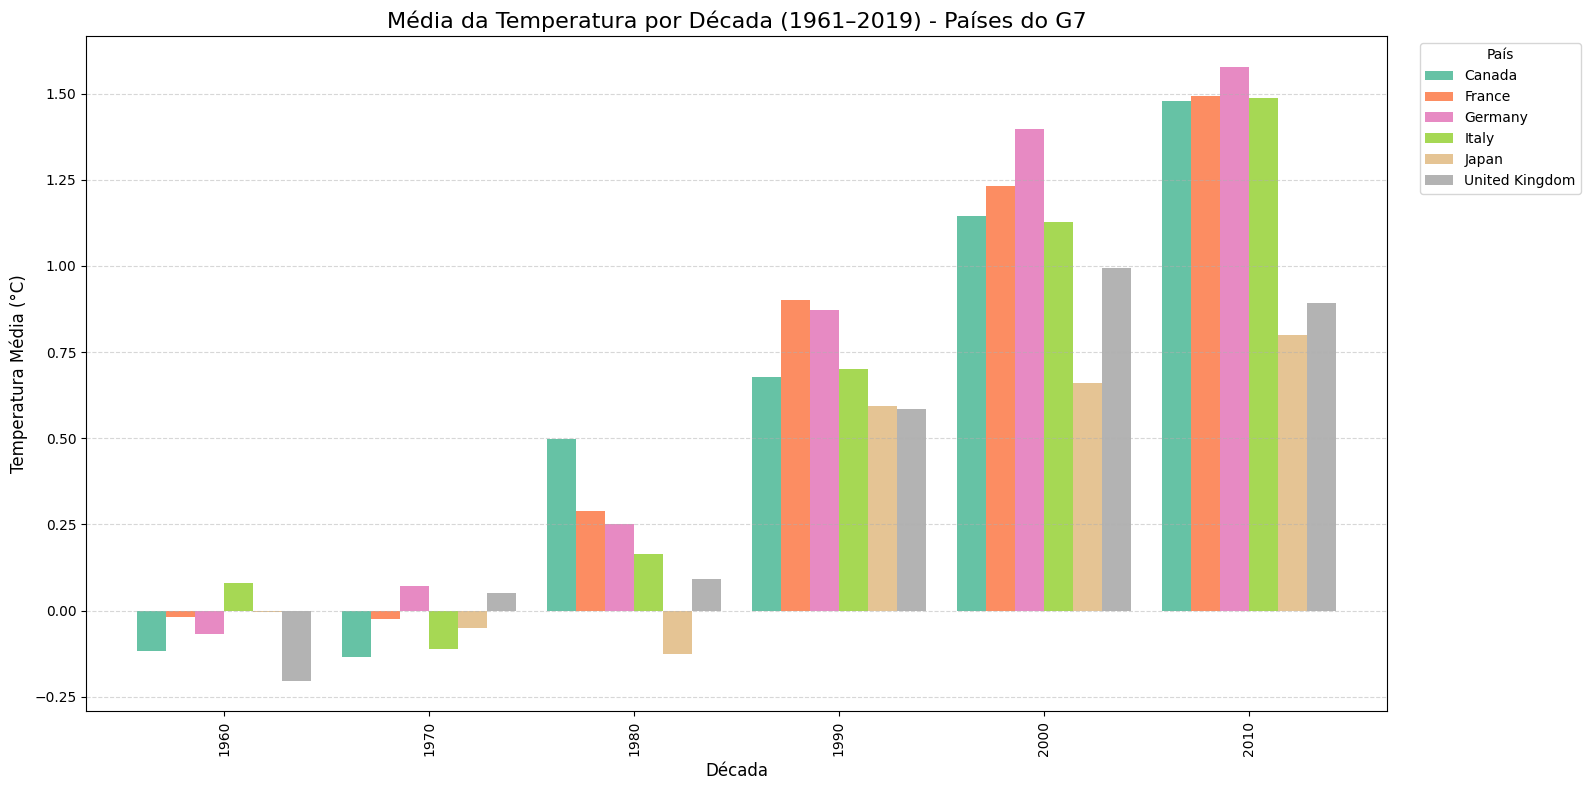

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carregar e limpar os dados
df = pd.read_csv("../data/Environment_Temperature_change_E_All_Data_NOFLAG.csv", encoding="ISO-8859-1")
df.columns = df.columns.str.replace("ï»¿", "")
df = df[df["Element"] == "Temperature change"]

df_long = df.melt(
    id_vars=["Area", "Months", "Element", "Unit"],
    value_vars=[col for col in df.columns if col.startswith("Y")],
    var_name="Year",
    value_name="Value"
)
df_long["Year"] = df_long["Year"].str.extract("(\d+)").astype(int)
df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")
df_long.dropna(subset=["Value"], inplace=True)

# 2. Filtrar países do G7 e "Meteorological year"
g7_paises = ["United States", "Canada", "Germany", "France", "United Kingdom", "Italy", "Japan"]
df_g7 = df_long[
    (df_long["Area"].isin(g7_paises)) &
    (df_long["Months"] == "Meteorological year") &
    (df_long["Year"].between(1961, 2019))
]

# 3. Criar coluna com década (ex: 1960, 1970, ..., 2010)
df_g7["Decade"] = (df_g7["Year"] // 10) * 10

# 4. Agrupar por década e país, tirando média
df_decadas = df_g7.groupby(["Decade", "Area"])["Value"].mean().reset_index()

# 5. Pivotar para gráfico de barras agrupadas
df_pivot = df_decadas.pivot(index="Decade", columns="Area", values="Value")

# 6. Plotar gráfico
df_pivot.plot(kind="bar", figsize=(16, 8), width=0.85, colormap="Set2")

plt.title("Média da Temperatura por Década (1961–2019) - Países do G7", fontsize=16)
plt.xlabel("Década", fontsize=12)
plt.ylabel("Temperatura Média (°C)", fontsize=12)
plt.legend(title="País", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
